# MSME Financial Health Card — EDA and the decisions it produced

This notebook is the **audit trail** for the design choices that are now frozen in
`params.yaml` and `src/`. Every number it quotes is recomputed here from the raw
file, with the charts that made the decision obvious.

It is deliberately *not* part of the pipeline. Nothing the system depends on is
produced here — the notebook calls the same functions the pipeline calls
(`load_raw`, `preprocess`, `add_derived_features`), so it can
never drift into being a second, untested implementation of the feature logic.
When a chart below implies a threshold, the threshold lives in `params.yaml` and
the code that reads it lives in `src/`; each section ends with that pointer.

**Run it:**

```bash
uv sync --all-groups
uv run jupyter lab notebooks/01_eda_and_feature_design.ipynb
# or, headless:
uv run jupyter nbconvert --to notebook --execute --inplace \
    notebooks/01_eda_and_feature_design.ipynb
```

---

## Contents

| § | Question | Decision it produced |
|---|---|---|
| 1 | What is actually in the file? | the 33-column feature allowlist |
| 2 | Where are the NULLs and why? | structural nulls, never imputed |
| 3 | How heavy are the tails? | winsorise at the 1st/99th percentile |
| 4 | Do thin-file firms score worse? | fairness as a gate, not a footnote |
| 5 | Which ratios would a credit officer compute? | the 14 derived features |
| 6 | What is redundant? | the correlation census |
| 7 | Should redundant features be dropped? | measured, then answered |
| 8 | Do the drivers separate risk visually? | pairplots by risk band |
| 9 | Where do the labels come from? | the hybrid architecture |
| 10 | Where should the grade edges sit? | bands on risk, not round numbers |
| 11 | Can a label leak into a model? | the allowlist firewall |
| 12 | Finding → code map | — |

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# src.utils.logger resolves LOG_DIR relative to the working directory, which for a
# kernel is notebooks/. Point it at the project's own log directory before the first
# src import, so running this notebook does not litter a second one.
import os  # noqa: E402

os.environ.setdefault("LOG_DIR", str(ROOT / "logs"))

warnings.filterwarnings("ignore", category=FutureWarning)
# The pipeline logs one structured JSON line per stage. That is exactly what is
# wanted in CloudWatch and exactly what is not wanted between two charts, so the
# notebook keeps only warnings and above.
import logging  # noqa: E402

logging.getLogger("src").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from src.utils.config import load_config  # noqa: E402

CFG = load_config()
SCHEMA = CFG["schema"]
ID = SCHEMA["id_column"]
print(f"repo root      : {ROOT}")
print(f"policy_version : {CFG['policy_version']}   rubric_version: {CFG['rubric_version']}")

repo root      : /home/saurabh/healthcard
policy_version : policy-1.0.0   rubric_version: rubric-1.0.0


### Chart theme

One place for the palette so every figure below reads as one system. The
categorical hues are assigned in a **fixed order** (never cycled), correlation
uses a **diverging** blue↔red ramp with a neutral grey midpoint because the sign
of `r` is the point, and density uses a **single-hue** blue ramp because it
encodes magnitude only. Risk bands get the reserved **status** colours and always
carry a legend label, so identity is never colour-alone.

In [2]:
import matplotlib as mpl  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import seaborn as sns  # noqa: E402
from matplotlib.colors import LinearSegmentedColormap  # noqa: E402

SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

# Categorical slots, in order. Scatter/pairplot forms use the first three only —
# past three the all-pairs colourblind separation no longer clears the floor.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
# Reserved status colours. Risk band is a state, not a series.
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
RISK_COLORS = {"Low": STATUS["good"], "Medium": STATUS["warning"], "High": STATUS["critical"]}

BLUES = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
         "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("hc_seq", BLUES)
# Equal step count per arm, neutral grey at zero. The dark red end is the palette
# red darkened on its own hue, so the two arms reach comparable weight.
_dark_red = "#%02x%02x%02x" % tuple(int(int(SERIES[7][i : i + 2], 16) * 0.6) for i in (1, 3, 5))
DIV = LinearSegmentedColormap.from_list(
    "hc_div", [_dark_red, SERIES[7], "#f0efec", SERIES[0], "#0d366b"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    # 92 dpi keeps the rendered notebook a reasonable size to commit; the charts
    # are still legible at full width on a laptop screen.
    "figure.dpi": 92, "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": MUTED,
    "ytick.labelcolor": MUTED,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 8.5,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "patch.linewidth": 0.0,
    "xtick.major.size": 0, "ytick.major.size": 0,
})
sns.set_palette(SERIES)


def lakh(x: float, _pos: int | None = None) -> str:
    """Indian-scale money tick labels: L = lakh (1e5), Cr = crore (1e7)."""
    if x >= 1e7:
        return f"{x / 1e7:,.1f}Cr"
    if x >= 1e5:
        return f"{x / 1e5:,.0f}L"
    return f"{x:,.0f}"


MONEY = mpl.ticker.FuncFormatter(lakh)
COMMA = mpl.ticker.FuncFormatter(lambda v, _p: f"{v:,.0f}")


def titled(ax, title: str, subtitle: str | None = None, xlabel: str = "", ylabel: str = ""):
    """Title + optional one-line 'so what' under it, in secondary ink."""
    ax.set_title(title, pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=INK_2, fontsize=8.5,
                va="bottom", ha="left")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax


def header(fig, title: str, subtitle: str | None = None) -> None:
    """Figure-level title block. Reserves its space in inches, so it never collides
    with the first row of axes whatever the figure height."""
    height = fig.get_size_inches()[1]
    fig.text(0.005, 1 - 0.16 / height, title, va="top", ha="left", fontsize=11,
             color=INK, weight="bold")
    if subtitle:
        fig.text(0.005, 1 - 0.40 / height, subtitle, va="top", ha="left", fontsize=8.5,
                 color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, 1 - (0.62 if subtitle else 0.36) / height))


def annotated_heatmap(ax, frame: pd.DataFrame, fmt: str = "{:.3f}") -> None:
    """imshow + per-cell labels, each inked for contrast against its own cell."""
    ax.imshow(frame.values, cmap=DIV, vmin=-1, vmax=1)
    ax.set_xticks(range(len(frame.columns)), frame.columns, rotation=40, ha="right",
                  fontsize=7.5)
    ax.set_yticks(range(len(frame.index)), frame.index, fontsize=7.5)
    ax.set_xticks(np.arange(len(frame.columns) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(frame.index) + 1) - 0.5, minor=True)
    # A 2px surface gap between cells, so adjacent fills stay separate marks.
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    for row in range(frame.shape[0]):
        for column in range(frame.shape[1]):
            value = frame.iat[row, column]
            ax.text(column, row, fmt.format(value), ha="center", va="center", fontsize=7.5,
                    color=SURFACE if abs(value) > 0.55 else INK)


print("theme ready")

theme ready


---
## 1. What is actually in the file?

The loader is the first gate of the leakage firewall, so the census matters: every
column is either the identifier, one of the allowlisted inputs, or supervision.
There is no fourth category, and a column that appears later without being
classified is a bug.

In [3]:
from src.data.data_loader import load_raw, split_features_labels  # noqa: E402

raw = load_raw(config=CFG)

census = pd.DataFrame(
    [
        ("identifier", 1, ID),
        ("input features (allowlist)", len(SCHEMA["feature_columns"]), "…33 columns"),
        ("supervision targets", len(SCHEMA["label_columns"]), "…11 columns"),
    ],
    columns=["role", "columns", "example"],
)
unclassified = set(raw.columns) - {ID} - set(SCHEMA["feature_columns"]) - set(SCHEMA["label_columns"])
print(f"raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"unclassified columns: {sorted(unclassified) or 'none'}")
census

raw shape: 50,000 rows x 45 columns
unclassified columns: none


,role,columns,example
0,identifier,1,MSME_ID
1,input features (allowlist),33,…33 columns
2,supervision targets,11,…11 columns


The 33 inputs are not a flat list — they arrive from six independent rails, and
that provenance is what later makes *triangulation* possible: GSTN, the bank
statement and the firm's own declared turnover are three separate witnesses to the
same revenue.

In [4]:
SOURCES = {
    "Firmographics": ["Customer_Segment", "Business_Type", "Industry", "Location_Category",
                      "Years_in_Operation", "Employee_Count", "Annual_Turnover_INR"],
    "GSTN": ["Monthly_GST_Sales_INR", "Monthly_GST_Purchases_INR", "GST_Filing_Timeliness_Pct",
             "GST_Return_Frequency"],
    "UPI": ["Monthly_UPI_Inflow_INR", "Monthly_UPI_Outflow_INR", "UPI_Avg_Ticket_Size_INR",
            "UPI_Daily_Txn_Count", "Transaction_Volatility_Index"],
    "Bank / AA": ["Monthly_Bank_Credits_INR", "Monthly_Bank_Debits_INR", "Average_Bank_Balance_INR",
                  "Cashflow_Stability_Index", "Overdraft_Usage_Ratio"],
    "Credit bureau": ["Has_Existing_Loan", "Monthly_Loan_EMI_INR", "EMI_On_Time_Rate_Pct",
                      "Credit_History_Months"],
    "EPFO / payroll": ["Monthly_Payroll_INR", "Salary_Consistency_Pct",
                       "Employee_Attrition_Rate_Pct"],
    "Invoices": ["Avg_Invoice_Payment_Delay_Days", "Customer_Concentration_Ratio",
                 "Vendor_Payment_Timeliness_Pct"],
    "Trend": ["Seasonality_Index", "Revenue_Growth_Rate_Pct"],
}
by_source = pd.DataFrame(
    [(src, len(cols), ", ".join(c.replace("_INR", "").replace("_Pct", "") for c in cols))
     for src, cols in SOURCES.items()],
    columns=["rail", "n", "columns"],
)
assert sum(len(c) for c in SOURCES.values()) == len(SCHEMA["feature_columns"])
by_source

,rail,n,columns
0,Firmographics,7,"Customer_Segment, Business_Type, Industry, Loc..."
1,GSTN,4,"Monthly_GST_Sales, Monthly_GST_Purchases, GST_..."
2,UPI,5,"Monthly_UPI_Inflow, Monthly_UPI_Outflow, UPI_A..."
3,Bank / AA,5,"Monthly_Bank_Credits, Monthly_Bank_Debits, Ave..."
4,Credit bureau,4,"Has_Existing_Loan, Monthly_Loan_EMI, EMI_On_Ti..."
5,EPFO / payroll,3,"Monthly_Payroll, Salary_Consistency, Employee_..."
6,Invoices,3,"Avg_Invoice_Payment_Delay_Days, Customer_Conce..."
7,Trend,2,"Seasonality_Index, Revenue_Growth_Rate"


---
## 2. Where are the NULLs, and why?

This is the single most consequential finding in the dataset. There is exactly one
column with missing values — and its missingness is not random.

In [5]:
nulls = raw.isna().sum()
nulls = nulls[nulls > 0].rename("null_rows").to_frame()
nulls["pct"] = (nulls["null_rows"] / len(raw) * 100).round(2)
nulls

,null_rows,pct
EMI_On_Time_Rate_Pct,32556,65.1100


In [6]:
no_loan = raw["Has_Existing_Loan"].astype("string").eq("No")
emi_null = raw["EMI_On_Time_Rate_Pct"].isna()

print("crosstab — EMI_On_Time_Rate_Pct nullness vs Has_Existing_Loan")
print(pd.crosstab(emi_null.rename("emi_is_null"), raw["Has_Existing_Loan"], margins=True))
print()
print(f"identical, not merely correlated: {bool((emi_null == no_loan).all())}")
print(f"rows with no repayment track record: {int(no_loan.sum()):,} "
      f"({no_loan.mean():.1%} of the portfolio)")

crosstab — EMI_On_Time_Rate_Pct nullness vs Has_Existing_Loan
Has_Existing_Loan     No    Yes    All
emi_is_null                           
False                  0  17444  17444
True               32556      0  32556
All                32556  17444  50000

identical, not merely correlated: True
rows with no repayment track record: 32,556 (65.1% of the portfolio)


`(nulls == no_loan).all() → True`. Not 99.8% — **identical**. So the NULL is not a
measurement failure to be patched over; it is a *fact about the firm*: it has never
borrowed. Imputing the portfolio mean would invent a repayment history for 65% of
the book, and would do so most damagingly for exactly the new-to-credit firms this
system exists to serve.

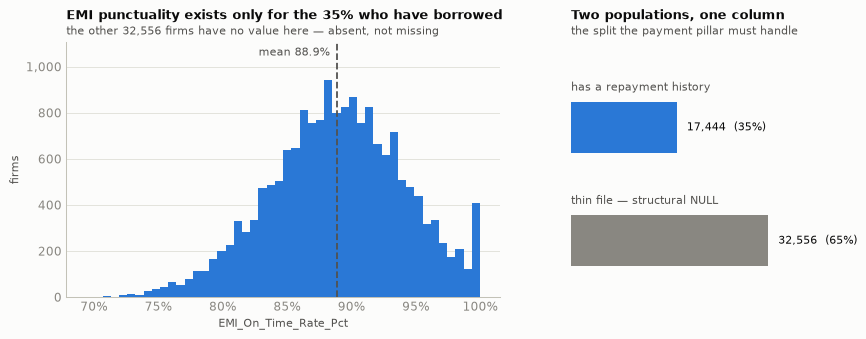

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), width_ratios=[1.55, 1])

holders = raw.loc[~no_loan, "EMI_On_Time_Rate_Pct"]
ax = axes[0]
ax.hist(holders, bins=48, color=SERIES[0])
ax.axvline(holders.mean(), color=INK_2, lw=1.4, ls="--")
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.annotate(f"mean {holders.mean():.1f}%", (holders.mean(), ax.get_ylim()[1]),
            xytext=(-6, -4), textcoords="offset points", ha="right", va="top", color=INK_2,
            fontsize=8.5)
ax.yaxis.set_major_formatter(COMMA)
titled(ax, "EMI punctuality exists only for the 35% who have borrowed",
       "the other 32,556 firms have no value here — absent, not missing",
       "EMI_On_Time_Rate_Pct", "firms")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100, decimals=0))

ax = axes[1]
counts = pd.Series({"thin file — structural NULL": int(no_loan.sum()),
                    "has a repayment history": int((~no_loan).sum())})
bars = ax.barh(range(len(counts)), counts.to_numpy(), color=[MUTED, SERIES[0]], height=0.45)
for position, (label, value) in enumerate(counts.items()):
    ax.annotate(label, (0, position + 0.30), color=INK_2, fontsize=8.5, va="bottom")
    ax.annotate(f"{value:,}  ({value / len(raw):.0%})", (value, position), xytext=(8, 0),
                textcoords="offset points", va="center", color=INK, fontsize=8.5)
ax.set_xlim(0, counts.max() * 1.42)
ax.set_ylim(-0.5, len(counts) - 0.25)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
for side in ("left", "bottom"):
    ax.spines[side].set_visible(False)
titled(ax, "Two populations, one column", "the split the payment pillar must handle")
plt.show()

> **Decision.** Structural nulls are declared, asserted and never imputed.
>
> * `params.yaml` → `schema.structural_null_columns: {EMI_On_Time_Rate_Pct: "Has_Existing_Loan == 'No'"}`
> * `src/data/data_validator.py` → `_check_structural_nulls` **fails the pipeline**
>   if that identity ever stops holding, because the payment pillar would then
>   silently mis-score 65% of the book.
> * `src/data/feature_engineer.py` → adds `has_repayment_history` so absence is an
>   explicit signal, and leaves the rate itself NaN.
> * `src/scoring/pillars.py` → the `emi_on_time_rate` driver is `optional: true`;
>   its rubric weight is redistributed pro-rata and a `thin_file` flag is raised.
> * XGBoost handles the NaN natively (`enable_categorical`/`hist`), so no imputation
>   enters the model path either.

---
## 3. How heavy are the tails?

Money columns in an MSME portfolio span four orders of magnitude — a ₹3 lakh
roadside trader and a ₹40 crore manufacturer sit in the same file. Before deciding
anything about clipping, measure the skew.

In [8]:
numeric_inputs = [c for c in SCHEMA["feature_columns"]
                  if c not in SCHEMA["categorical_columns"]]
skew = (raw[numeric_inputs].skew().rename("skew").to_frame()
        .assign(kurtosis=raw[numeric_inputs].kurtosis(),
                p50=raw[numeric_inputs].median(),
                p99=raw[numeric_inputs].quantile(0.99),
                max=raw[numeric_inputs].max())
        .sort_values("skew", ascending=False))
skew["p99_to_max"] = (skew["max"] / skew["p99"]).round(2)
skew.head(12)

,skew,kurtosis,p50,p99,max,p99_to_max
Monthly_Loan_EMI_INR,9.5882,187.2415,0.0000,"660,581.0600","5,786,952.0000",8.7600
UPI_Avg_Ticket_Size_INR,8.1762,145.3430,491.0000,"7,114.0600","60,980.0000",8.5700
Monthly_UPI_Inflow_INR,7.7560,137.0125,"129,439.5000","1,718,943.5400","13,510,987.0000",7.8600
Monthly_UPI_Outflow_INR,7.4494,119.5333,"72,570.5000","1,049,578.9000","8,168,324.0000",7.7800
Average_Bank_Balance_INR,6.7694,86.4882,"195,073.0000","2,729,154.2400","16,658,805.0000",6.1000
Monthly_Bank_Debits_INR,5.9192,69.8868,"326,745.0000","3,644,340.3800","23,245,063.0000",6.3800
Monthly_GST_Purchases_INR,5.8163,63.6246,"249,107.5000","2,908,300.4500","15,472,028.0000",5.3200
Monthly_Bank_Credits_INR,5.7254,63.3252,"413,055.0000","4,582,727.4600","27,122,069.0000",5.9200
Monthly_GST_Sales_INR,5.6321,59.4363,"401,682.0000","4,460,090.6200","23,040,392.0000",5.1700
Annual_Turnover_INR,5.5938,58.0884,"4,928,700.0000","54,293,332.7200","254,885,957.0000",4.6900


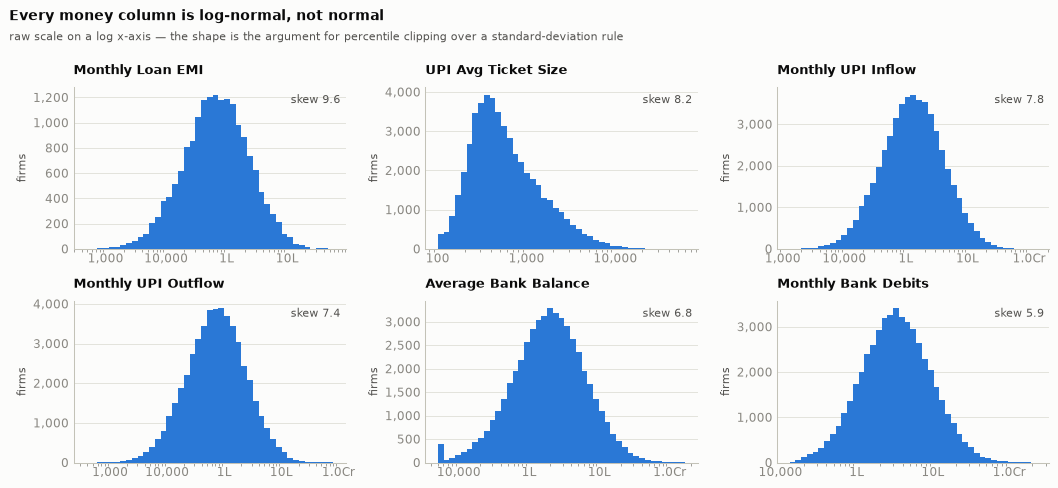

In [9]:
heavy = skew.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.4))
for ax, col in zip(axes.ravel(), heavy):
    series = raw[col].dropna()
    positive = series[series > 0]
    ax.hist(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 44),
            color=SERIES[0])
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(MONEY)
    titled(ax, col.replace("_INR", "").replace("_", " "), None, "", "firms")
    ax.yaxis.set_major_formatter(COMMA)
    ax.text(0.98, 0.9, f"skew {series.skew():.1f}", transform=ax.transAxes, ha="right",
            color=INK_2, fontsize=8.5)
header(fig, "Every money column is log-normal, not normal",
       "raw scale on a log x-axis — the shape is the argument for percentile clipping "
       "over a standard-deviation rule")
plt.show()

A ±3σ rule on a distribution this skewed clips the wrong tail and keeps absurd
values in the other, so the bounds are **percentiles the data chooses**. The
remaining question is which percentiles: aggressive clipping stabilises the model
but destroys the top of the book, and the credit-limit target is proportional to
turnover, so over-clipping turnover directly breaks limit accuracy.

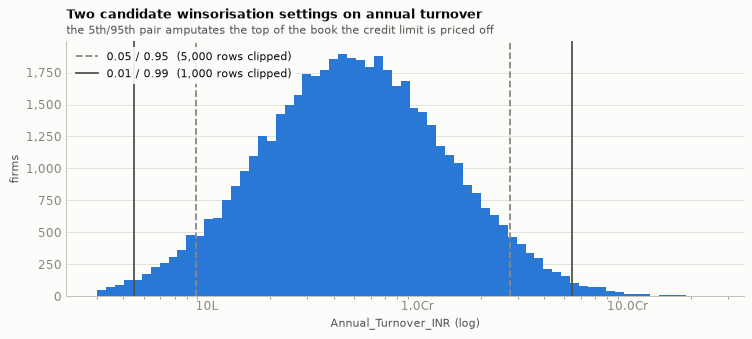

,lower_inr,upper_inr,rows_clipped,turnover_mass_lost_pct
setting,,,,
0.05 / 0.95,"889,956.0500","27,495,392.5500",5000,10.6700
0.01 / 0.99,"448,888.4500","54,293,332.7200",1000,3.4100


In [10]:
col = "Annual_Turnover_INR"
series = raw[col]
choices = {"0.05 / 0.95": (0.05, 0.95), "0.01 / 0.99": (0.01, 0.99)}
impact = pd.DataFrame(
    [
        {
            "setting": name,
            "lower_inr": series.quantile(lo),
            "upper_inr": series.quantile(hi),
            "rows_clipped": int(((series < series.quantile(lo)) | (series > series.quantile(hi))).sum()),
            "turnover_mass_lost_pct": round(
                (series.sum() - series.clip(series.quantile(lo), series.quantile(hi)).sum())
                / series.sum() * 100, 2),
        }
        for name, (lo, hi) in choices.items()
    ]
).set_index("setting")

fig, ax = plt.subplots(figsize=(9.5, 3.6))
positive = series[series > 0]
ax.hist(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 70),
        color=SERIES[0])
for (name, (lo, hi)), color, ls in zip(choices.items(), (MUTED, INK_2), ("--", "-")):
    for q in (lo, hi):
        ax.axvline(series.quantile(q), color=color, lw=1.4, ls=ls)
    ax.plot([], [], color=color, lw=1.4, ls=ls, label=f"{name}  ({impact.loc[name, 'rows_clipped']:,} rows clipped)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(MONEY)
ax.yaxis.set_major_formatter(COMMA)
ax.legend(loc="upper left", frameon=True, facecolor=SURFACE, edgecolor="none", framealpha=0.9)
titled(ax, "Two candidate winsorisation settings on annual turnover",
       "the 5th/95th pair amputates the top of the book the credit limit is priced off",
       "Annual_Turnover_INR (log)", "firms")
plt.show()
impact

> **Decision.** Winsorise at the **1st/99th** percentile, fitted once and persisted.
>
> * `params.yaml` → `preprocessing.winsorise.{lower_quantile: 0.01, upper_quantile: 0.99}`
>   over 11 money columns.
> * The 5th/95th pair was tried first and **breached the limit-accuracy gate**
>   (`evaluation.thresholds.limit_mape_max: 0.15`): the recommended limit is a
>   percentage of turnover, so flattening the top 5% of turnover flattens the
>   limit with it. Loosening to 1/99 fixed the breach — the gate chose the number.
> * `src/data/data_preprocessor.py` → `fit_winsor_limits` / `apply_winsor_limits`.
>   Limits are fitted on the training portfolio, written to
>   `data/processed/winsor_limits.json`, and **reloaded at inference** so a single
>   real-time card is clipped against the same bounds as the training batch.
> * `src/data/data_validator.py` deliberately does *not* own these bounds. Its range
>   check reads definitional domains off `MSMEFeatures`; unusual-but-legal values
>   are winsorisation's job, not validation's.

---
## 4. Do thin-file firms score worse?

The dataset's segment mix is the whole thesis of the exercise, and it is worth
looking at before any modelling — because if the answer is "yes", a model that
reproduces it has recreated the exclusion the system exists to remove.

In [11]:
seg = (raw.groupby("Customer_Segment", observed=True)
       .agg(firms=(ID, "size"),
            mean_fhs=("Financial_Health_Score", "mean"),
            mean_pd=("Probability_of_Default", "mean"),
            eligible_pct=("Credit_Eligible", lambda s: s.astype("string").eq("Yes").mean() * 100))
       .sort_values("firms", ascending=False).round(2))
seg

,firms,mean_fhs,mean_pd,eligible_pct
Customer_Segment,,,,
NTC,21068,74.2900,0.1200,72.6100
NTB,14967,74.5200,0.1200,73.6900
Existing-to-Credit,13965,75.4000,0.1100,77.6200


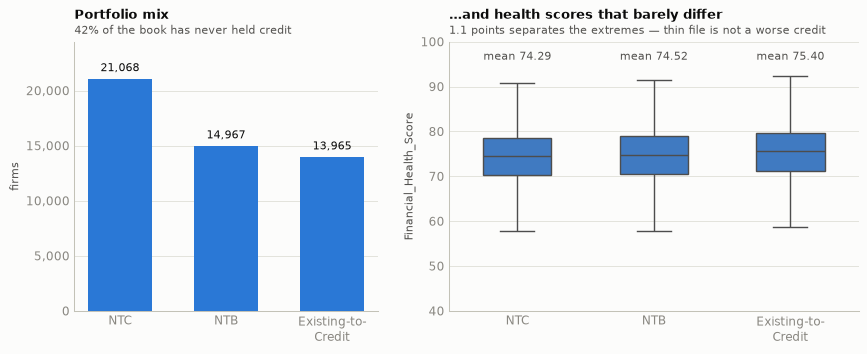

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), width_ratios=[1, 1.35])

ax = axes[0]
bars = ax.bar(seg.index, seg["firms"], color=SERIES[0], width=0.6)
ax.bar_label(bars, labels=[f"{v:,}" for v in seg["firms"]], padding=4, color=INK, fontsize=8.5)
ax.set_ylim(0, seg["firms"].max() * 1.16)
ax.yaxis.set_major_formatter(COMMA)
ax.set_xticks(range(len(seg)), [i.replace("-to-", "-to-\n") for i in seg.index])
titled(ax, "Portfolio mix", "42% of the book has never held credit", "", "firms")

ax = axes[1]
order = list(seg.index)
sns.boxplot(data=raw, x="Customer_Segment", y="Financial_Health_Score", order=order,
            color=SERIES[0], width=0.5, fliersize=0, linewidth=1.1, ax=ax)
for i, name in enumerate(order):
    ax.annotate(f"mean {seg.loc[name, 'mean_fhs']:.2f}", (i, 96), ha="center", color=INK_2,
                fontsize=8.5)
ax.set_ylim(40, 100)
ax.set_xticks(range(len(order)), [i.replace("-to-", "-to-\n") for i in order])
titled(ax, "…and health scores that barely differ",
       "1.1 points separates the extremes — thin file is not a worse credit",
       "", "Financial_Health_Score")
plt.show()

1.11 points of mean FHS separates new-to-credit from existing-to-credit firms. The
generator is making a statement, and it is the correct one: **absence of a credit
history is absence of evidence, not evidence of risk.**

> **Decision.** Fairness is a gate, not a report.
>
> * `params.yaml` → `model_params.fairness_slice_columns`,
>   `evaluation.thresholds.fairness_max_deviation_points: 3.0`.
> * `src/model/fairness.py` computes per-slice metrics during training; they are
>   logged to MLflow as first-class metrics and rendered on the metrics dashboard.
> * `pytest -m eval` asserts the deviation threshold, so a model that reintroduces
>   a segment penalty fails the build.
> * `Customer_Segment` is also the **stratification key** for the train/test split
>   (`model_params.stratify_column`), so the split cannot itself skew the mix.

### The ordinal encodings

Three categoricals feed rubric drivers, and a rubric driver needs a *number* with a
defensible direction. Rather than one-hot (which a transparent rubric cannot
narrate) each level is mapped onto 0–1 by standing. That mapping is a judgement
call, so it is worth checking against the data rather than asserting — and the
check comes back negative, which is more interesting than if it had passed.

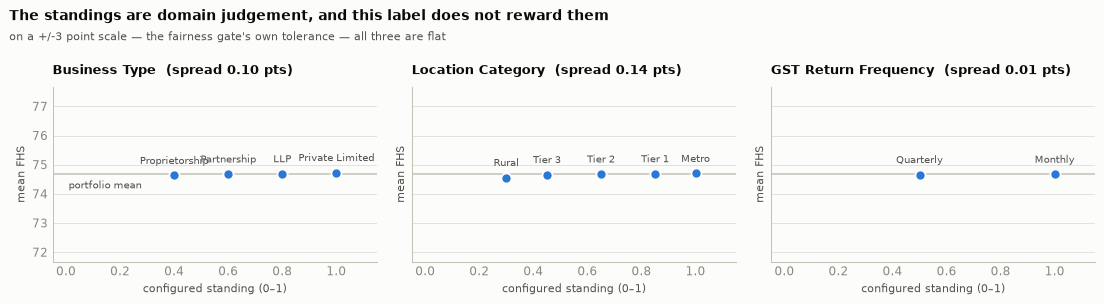

,column,level,configured_standing,firms,mean_fhs
0,Business_Type,Proprietorship,0.4000,24090,74.6300
1,Business_Type,Partnership,0.6000,10899,74.6800
2,Business_Type,LLP,0.8000,3988,74.6900
3,Business_Type,Private Limited,1.0000,11023,74.7300
4,Location_Category,Rural,0.3000,5091,74.5600
5,Location_Category,Tier 3,0.4500,10158,74.6600
6,Location_Category,Tier 2,0.6500,14833,74.6800
7,Location_Category,Tier 1,0.8500,10921,74.6900
8,Location_Category,Metro,1.0000,8997,74.7000
9,GST_Return_Frequency,Quarterly,0.5000,9068,74.6600


In [13]:
standing = CFG["categorical_standing"]
rows = []
for target, source in [("business_type_standing", "Business_Type"),
                       ("location_standing", "Location_Category"),
                       ("gst_return_frequency_standing", "GST_Return_Frequency")]:
    grouped = raw.groupby(source, observed=True)["Financial_Health_Score"].agg(["size", "mean"])
    for level, value in standing[target].items():
        rows.append({"column": source, "level": level, "configured_standing": value,
                     "firms": int(grouped.loc[level, "size"]),
                     "mean_fhs": round(grouped.loc[level, "mean"], 2)})
standing_check = pd.DataFrame(rows)

portfolio_mean = raw["Financial_Health_Score"].mean()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (source, group) in zip(axes, standing_check.groupby("column", sort=False)):
    group = group.sort_values("configured_standing")
    ax.axhline(portfolio_mean, color=AXIS, lw=1.2)
    ax.scatter(group["configured_standing"], group["mean_fhs"], color=SERIES[0], zorder=3,
               edgecolor=SURFACE, linewidth=1.5)
    for _, r in group.iterrows():
        ax.annotate(r["level"], (r["configured_standing"], r["mean_fhs"]), xytext=(0, 9),
                    textcoords="offset points", ha="center", color=INK_2, fontsize=8)
    ax.set_xlim(-0.05, 1.15)
    spread = group["mean_fhs"].max() - group["mean_fhs"].min()
    titled(ax, f"{source.replace('_', ' ')}  (spread {spread:.2f} pts)", None,
           "configured standing (0–1)", "mean FHS")
# A truthful y-scale: +/-3 points, the fairness gate's own tolerance.
axes[0].set_ylim(portfolio_mean - 3, portfolio_mean + 3)
axes[0].annotate("portfolio mean", (0.0, portfolio_mean), xytext=(2, -11),
                 textcoords="offset points", color=INK_2, fontsize=8)
header(fig, "The standings are domain judgement, and this label does not reward them",
       "on a +/-3 point scale — the fairness gate's own tolerance — all three are flat")
plt.show()
standing_check

Constitution moves the mean health score by 0.10 points on a 100-point scale, and
locality by 0.15. That is not a weak signal, it is **no signal**: this generator
draws firmographics independently of financial outcomes. GST return frequency is
flat for the same reason.

The honest reading is not "the standings are wrong" — a Private Limited with audited
accounts genuinely *is* a different credit proposition from an unregistered
proprietorship, which is why lenders price them differently. It is that **this
dataset cannot confirm them**, and a decision has to be made about what to do with a
driver the data does not reward.

> **Decision.** Keep them, at a weight floor, and say so out loud.
>
> * `params.yaml` → `categorical_standing` holds the maps;
>   `src/data/data_preprocessor.py::map_categorical_standing` applies them.
> * A **pure** non-negative least-squares fit drives exactly these drivers to zero.
>   `src/scoring/pillar_calibration.py` therefore clamps every driver at
>   `WEIGHT_FLOOR = 0.03` and renormalises: *a driver being unused by a generator is
>   not evidence it is irrelevant to real MSME credit.* That floor is the one piece
>   of judgement in the whole calibration, and this chart is why it is there. The
>   realised weights land at ~0.028 — present, auditable, and small enough not to
>   distort the fit.
> * An **unmapped level yields NaN, never 0.0** — 0.0 would silently treat an
>   unrecognised business type as the worst possible one, whereas NaN makes the
>   driver unavailable and lets the rubric redistribute its weight.
>   `src/data/data_validator.py::_check_categoricals` fails the pipeline on a level
>   with no entry, so the NaN path is a safety net and not a plan.

---
## 5. Which ratios would a credit officer compute?

The raw columns are levels — rupees per month, days, percentages. A credit officer
does not underwrite levels; they underwrite **ratios**, because a ratio is
scale-free and therefore comparable across a ₹5 lakh trader and a ₹5 crore
manufacturer. The 14 derived features are exactly the ratios an analyst could
reproduce on paper, which is the constraint: an unexplainable feature cannot appear
in a reason code.

The notebook calls the pipeline's own functions here — `preprocess` then
`add_derived_features` — so nothing below can drift from what production computes.

In [14]:
from src.data.data_preprocessor import preprocess  # noqa: E402
from src.data.feature_engineer import (  # noqa: E402
    _DSCR_CAP,
    DERIVED_COLUMNS,
    add_derived_features,
)

features_raw, labels = split_features_labels(raw, CFG)
processed, winsor_limits = preprocess(features_raw, CFG)
derived = add_derived_features(processed, CFG)

print(f"allowlisted inputs      : {features_raw.shape[1] - 1}")
print(f"+ ordinal standings     : 3")
print(f"+ derived ratios        : {len(DERIVED_COLUMNS)}")
print(f"= columns after §5      : {derived.shape[1] - 1}")

DERIVED_DOC = {
    "has_repayment_history": "Has_Existing_Loan == Yes and the EMI rate is observed",
    "monthly_turnover_run_rate": "Annual_Turnover / 12",
    "net_monthly_cashflow": "bank credits − bank debits",
    "credit_debit_ratio": "bank credits / bank debits",
    "balance_days_of_outflow": "avg balance / (debits / 30) — the cash buffer, in days",
    "dscr_proxy": "(net cashflow + EMI) / EMI, capped at 25",
    "upi_share_of_credits": "UPI inflow / bank credits — a containment check",
    "purchases_to_sales_ratio": "GST purchases / GST sales — gross margin proxy",
    "gst_turnover_realisation": "GST sales / turnover run rate",
    "gst_bank_reconciliation_gap": "|GST sales − bank credits| / max(the two)",
    "revenue_triangulation_gap": "worst disagreement among the revenue witnesses",
    "payroll_to_turnover_ratio": "annualised payroll / turnover",
    "turnover_per_employee": "turnover / headcount — productivity",
    "contraction_overdraft_signal": "revenue contracting AND overdraft elevated",
}
pd.DataFrame({"feature": list(DERIVED_DOC), "computed as": list(DERIVED_DOC.values())})

allowlisted inputs      : 33
+ ordinal standings     : 3
+ derived ratios        : 14
= columns after §5      : 50


,feature,computed as
0,has_repayment_history,Has_Existing_Loan == Yes and the EMI rate is o...
1,monthly_turnover_run_rate,Annual_Turnover / 12
2,net_monthly_cashflow,bank credits − bank debits
3,credit_debit_ratio,bank credits / bank debits
4,balance_days_of_outflow,"avg balance / (debits / 30) — the cash buffer,..."
5,dscr_proxy,"(net cashflow + EMI) / EMI, capped at 25"
6,upi_share_of_credits,UPI inflow / bank credits — a containment check
7,purchases_to_sales_ratio,GST purchases / GST sales — gross margin proxy
8,gst_turnover_realisation,GST sales / turnover run rate
9,gst_bank_reconciliation_gap,|GST sales − bank credits| / max(the two)


### Why every division is floored

Two of these denominators are legitimately zero for real firms. A naive division
would produce `inf`, and `inf` becomes a silent NaN the moment it meets a
groupby — a feature that quietly stops existing for the most distressed firms in
the book.

In [15]:
denominators = {
    "Monthly_Bank_Debits_INR": "credit_debit_ratio, balance_days_of_outflow",
    "Monthly_Bank_Credits_INR": "upi_share_of_credits, gst_bank_reconciliation_gap",
    "Monthly_GST_Sales_INR": "purchases_to_sales_ratio",
    "Monthly_Loan_EMI_INR": "dscr_proxy",
    "Employee_Count": "turnover_per_employee",
}
floor = float(CFG["preprocessing"]["min_denominator"])
pd.DataFrame(
    [{"denominator": col,
      "rows_at_zero": int((processed[col] == 0).sum()),
      "rows_below_floor": int((processed[col].abs() < floor).sum()),
      "feeds": feeds}
     for col, feeds in denominators.items()]
).set_index("denominator")

,rows_at_zero,rows_below_floor,feeds
denominator,,,
Monthly_Bank_Debits_INR,0,0,"credit_debit_ratio, balance_days_of_outflow"
Monthly_Bank_Credits_INR,0,0,"upi_share_of_credits, gst_bank_reconciliation_gap"
Monthly_GST_Sales_INR,0,0,purchases_to_sales_ratio
Monthly_Loan_EMI_INR,32556,32556,dscr_proxy
Employee_Count,0,0,turnover_per_employee


> **Decision.** `params.yaml` → `preprocessing.min_denominator: 1.0`, applied by
> `_safe_divide` in `src/data/feature_engineer.py`: the denominator is floored away
> from zero so a firm with no EMI yields a large-but-finite ratio. Any `inf` that
> still escapes is converted to NaN once, explicitly, at the end of the stage —
> NaN the learner handles; `inf` it does not.

### Two derived features worth looking at

`dscr_proxy` and `revenue_triangulation_gap` are the two that carry the most design
in them, so their distributions are the ones to check.

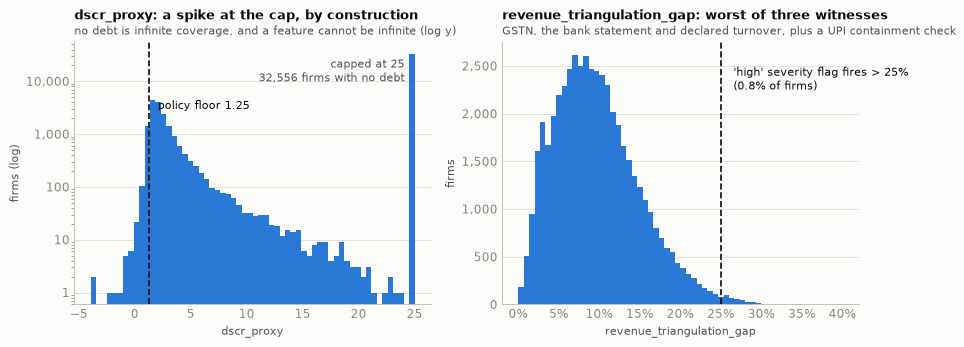

In [16]:
from src.scoring.anomaly import RULES  # noqa: E402

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))

ax = axes[0]
d = derived["dscr_proxy"]
ax.hist(d, bins=60, color=SERIES[0])
ax.set_yscale("log")            # the cap holds two thirds of the book: log, or see nothing
ax.yaxis.set_major_formatter(COMMA)
capped = int((d >= _DSCR_CAP - 1e-3).sum())
ax.annotate(f"capped at {_DSCR_CAP:.0f}\n{capped:,} firms with no debt", (_DSCR_CAP, 1e4),
            xytext=(-8, 0), textcoords="offset points", ha="right", color=INK_2, fontsize=8.5)
min_dscr = CFG["policy"]["limits"]["dscr_headroom"]["min_dscr"]
ax.axvline(min_dscr, color=INK, lw=1.3, ls="--")
ax.annotate(f"policy floor {min_dscr}", (min_dscr, 3e3), xytext=(7, 0),
            textcoords="offset points", color=INK, fontsize=8.5)
titled(ax, "dscr_proxy: a spike at the cap, by construction",
       "no debt is infinite coverage, and a feature cannot be infinite (log y)",
       "dscr_proxy", "firms (log)")

ax = axes[1]
g = derived["revenue_triangulation_gap"]
ax.hist(g, bins=60, color=SERIES[0])

threshold = next(r for r in RULES if r.code == "revenue_source_divergence").threshold
ax.axvline(threshold, color=INK, lw=1.3, ls="--")
ax.annotate(f"'high' severity flag fires > {threshold:.0%}\n"
            f"({(g > threshold).mean():.1%} of firms)",
            (threshold, ax.get_ylim()[1] * 0.82), xytext=(10, 0), textcoords="offset points",
            ha="left", color=INK, fontsize=8.5)
ax.yaxis.set_major_formatter(COMMA)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
titled(ax, "revenue_triangulation_gap: worst of three witnesses",
       "GSTN, the bank statement and declared turnover, plus a UPI containment check",
       "revenue_triangulation_gap", "firms")
plt.show()

`revenue_triangulation_gap` is deliberately the **maximum** of four disagreements,
not their average: a firm whose GST sales match its bank credits perfectly but
whose declared turnover is double both is not two-thirds consistent, it is
inconsistent. Averaging would launder exactly the signal the feature exists to
catch. `src/data/feature_engineer.py` builds it; the `revenue_source_divergence`
rule in `src/scoring/anomaly.py` turns it into a typed flag at 0.25.

---
## 6. What is redundant?

47 candidate features, most of them ratios built from the same 33 inputs. Some of
that is guaranteed to be duplication, and duplication has a specific cost here — it
is not accuracy (§7), it is **attribution**: two near-identical features split the
credit for one effect, and a reason code that says "your GST sales *and* your bank
credits *and* your turnover run-rate" is one finding stated three times.

The three `*_standing` ordinals from §4 are not in this matrix. They re-encode
`Business_Type`, `Location_Category` and `GST_Return_Frequency`, which XGBoost
already splits natively — and a partition split is strictly more expressive than a
fixed 0-1 ordering, so the ordinal buys nothing while halving the importance of its
own raw column. They exist for the rubric, which needs a monotone driver; the model
does not.


In [17]:
from src.model.components import model_feature_names  # noqa: E402

# The shipped model matrix is raw-only (see §8). The redundancy question is about the
# *candidate* pool — every column feature engineering produces — so correlate over that.
model_features = model_feature_names(derived, CFG)
candidate_features = [c for c in (*model_features, *DERIVED_COLUMNS)
                      if c in derived.columns]
numeric_features = [c for c in candidate_features
                    if pd.api.types.is_numeric_dtype(derived[c])]
corr = derived[numeric_features].corr()
print(f"shipped model features : {len(model_features)} (raw only)")
print(f"candidate pool         : {len(candidate_features)}  "
      f"({len(numeric_features)} numeric, "
      f"{len(candidate_features) - len(numeric_features)} categorical)")

undefined = corr.isna().stack()
undefined = undefined[undefined]
print(f"\nundefined correlations: {len(undefined) // 2} pair(s)")
for a, b in {frozenset(pair) for pair in undefined.index}:
    print(f"  {a} <-> {b}")


shipped model features : 33 (raw only)
candidate pool         : 47  (41 numeric, 6 categorical)

undefined correlations: 1 pair(s)
  EMI_On_Time_Rate_Pct <-> has_repayment_history


That undefined pair is §2 reappearing as an arithmetic fact, and it is worth
pausing on: `corr(EMI_On_Time_Rate_Pct, has_repayment_history)` cannot be computed
because on the 17,444 rows where the EMI rate is observed, the flag is constant
`True`. Pairwise-complete correlation has no variance to work with. The flag is not
a redundant copy of the rate — it is the only thing that is *observable* for the
other 32,556 firms. For the clustering below the pair is given maximum distance
rather than dropped.

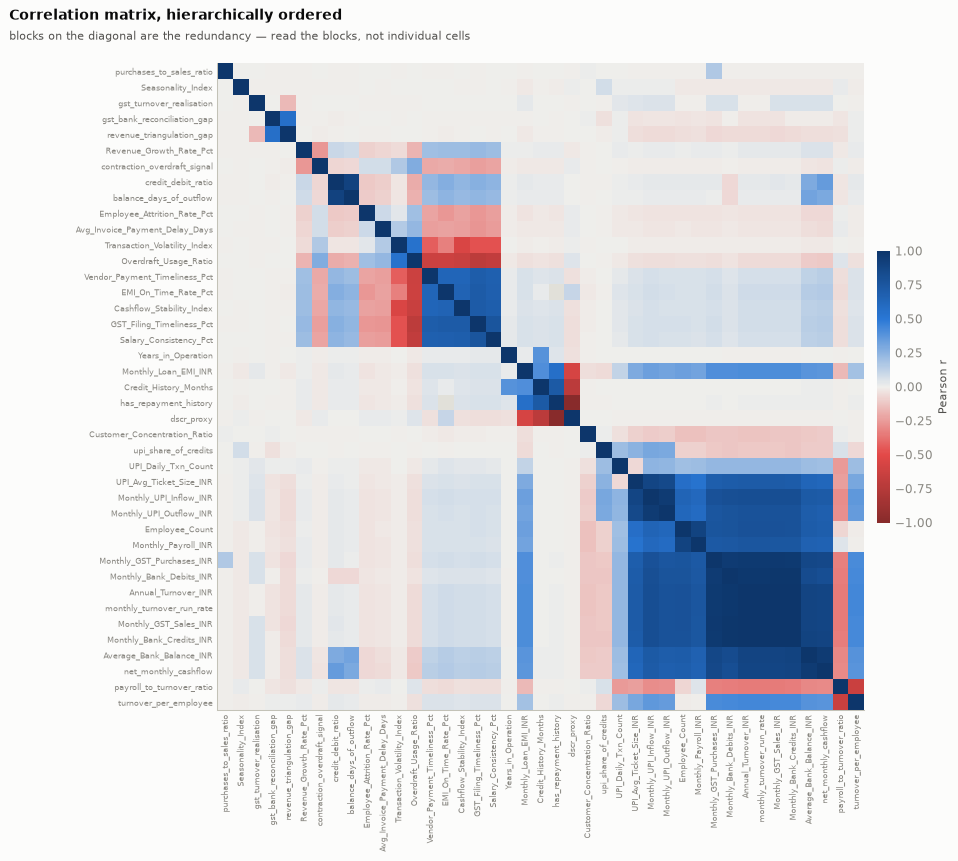

In [18]:
import scipy.cluster.hierarchy as sch  # noqa: E402
from scipy.spatial.distance import squareform  # noqa: E402

# An undefined correlation is not a strong one: treat it as maximally distant.
distance = (1.0 - corr.abs()).fillna(1.0)
np.fill_diagonal(distance.values, 0.0)
linkage = sch.linkage(squareform(distance.values, checks=False), method="average")
leaves = sch.leaves_list(linkage)
ordered = corr.iloc[leaves, leaves]

fig, ax = plt.subplots(figsize=(11, 9.4))
undefined_cmap = DIV.copy()
undefined_cmap.set_bad(GRID)      # the one undefined pair reads as chrome, not as zero
image = ax.imshow(ordered.values, cmap=undefined_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(ordered)), ordered.columns, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(ordered)), ordered.index, fontsize=6.5)
ax.grid(False)
bar = fig.colorbar(image, ax=ax, shrink=0.42, pad=0.015)
bar.set_label("Pearson r", color=INK_2, fontsize=8.5)
bar.outline.set_visible(False)
ax.set_title("")
header(fig, "Correlation matrix, hierarchically ordered",
       "blocks on the diagonal are the redundancy — read the blocks, not individual cells")
plt.show()

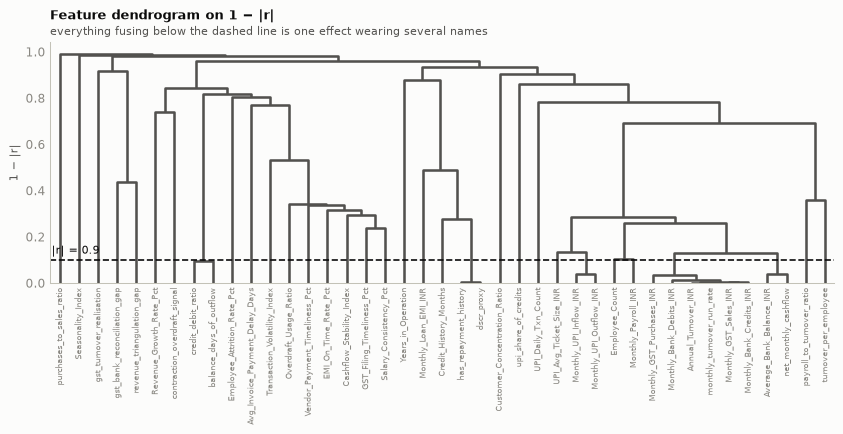

In [19]:
fig, ax = plt.subplots(figsize=(11, 3.4))
threshold = 0.9
sch.dendrogram(linkage, labels=corr.columns.tolist(), leaf_font_size=6.5,
               color_threshold=0, above_threshold_color=INK_2, ax=ax)
ax.axhline(1 - threshold, color=INK, lw=1.3, ls="--")
ax.annotate(f"|r| = {threshold}", (0.002, 1 - threshold), xycoords=("axes fraction", "data"),
            xytext=(0, 5), textcoords="offset points", ha="left", color=INK, fontsize=8.5)
ax.grid(False)
titled(ax, "Feature dendrogram on 1 − |r|",
       "everything fusing below the dashed line is one effect wearing several names",
       "", "1 − |r|")
plt.show()

In [20]:
pairs = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
redundant = (pairs[pairs > 0.9].sort_values(ascending=False).rename("abs_r").reset_index()
             .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
redundant["abs_r"] = redundant["abs_r"].round(4)
print(f"{len(redundant)} pairs above |r| = 0.9")
redundant

19 pairs above |r| = 0.9


,feature_a,feature_b,abs_r
0,Annual_Turnover_INR,monthly_turnover_run_rate,1.0000
1,Monthly_GST_Sales_INR,Monthly_Bank_Credits_INR,0.9968
2,Annual_Turnover_INR,Monthly_GST_Sales_INR,0.9953
3,Monthly_GST_Sales_INR,monthly_turnover_run_rate,0.9953
4,has_repayment_history,dscr_proxy,0.9936
5,Monthly_Bank_Credits_INR,monthly_turnover_run_rate,0.9922
6,Annual_Turnover_INR,Monthly_Bank_Credits_INR,0.9922
7,Monthly_Bank_Credits_INR,Monthly_Bank_Debits_INR,0.9898
8,Monthly_GST_Sales_INR,Monthly_Bank_Debits_INR,0.9862
9,Monthly_Bank_Debits_INR,monthly_turnover_run_rate,0.9819


One entry deserves singling out: `Annual_Turnover_INR` ↔ `monthly_turnover_run_rate`
at **r = 1.0000**. That is not a correlation, it is a unit conversion — the run-rate
exists because it is the *denominator* of `gst_turnover_realisation`, and it was
never intended as a model input in its own right. Everything else in the table is a
genuine economic relationship: in this portfolio a firm's declared GST sales, its
bank credits and its turnover are three measurements of one quantity.

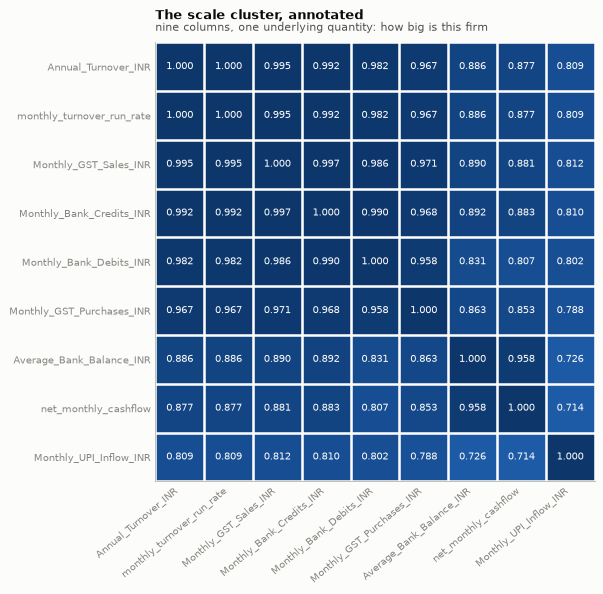

In [21]:
scale_cluster = ["Annual_Turnover_INR", "monthly_turnover_run_rate", "Monthly_GST_Sales_INR",
                 "Monthly_Bank_Credits_INR", "Monthly_Bank_Debits_INR",
                 "Monthly_GST_Purchases_INR", "Average_Bank_Balance_INR",
                 "net_monthly_cashflow", "Monthly_UPI_Inflow_INR"]
block = derived[scale_cluster].corr()

fig, ax = plt.subplots(figsize=(7.6, 6.2))
annotated_heatmap(ax, block)
titled(ax, "The scale cluster, annotated",
       "nine columns, one underlying quantity: how big is this firm")
plt.show()

---
## 7. Should the redundant features be dropped?

The textbook answer is yes. The textbook is thinking about a linear model, where
collinearity makes coefficients unstable and their signs meaningless. This system's
Layer B is **gradient-boosted trees**, which are indifferent to collinearity for
prediction — they simply pick one of the duplicates at each split.

So rather than assert either answer, prune and measure. Greedy prune: walk the
features in order, drop any that correlate above 0.9 with one already kept.

In [22]:
def greedy_prune(matrix: pd.DataFrame, threshold: float = 0.9) -> list[str]:
    """Columns to drop: each correlates > threshold with a column kept before it."""
    absolute = matrix.corr().abs()
    dropped: set[str] = set()
    columns = list(absolute.columns)
    for i, kept in enumerate(columns):
        if kept in dropped:
            continue
        for candidate in columns[i + 1:]:
            if candidate not in dropped and absolute.loc[kept, candidate] > threshold:
                dropped.add(candidate)
    return sorted(dropped)


to_drop = greedy_prune(derived[numeric_features])
pruned_features = [c for c in candidate_features if c not in to_drop]
print(f"dropped {len(to_drop)} of {len(candidate_features)} candidates -> {len(pruned_features)} kept\n")
pd.Series(to_drop, name="dropped at |r| > 0.9").to_frame()

dropped 9 of 47 candidates -> 38 kept



,dropped at |r| > 0.9
0,Monthly_Bank_Credits_INR
1,Monthly_Bank_Debits_INR
2,Monthly_GST_Purchases_INR
3,Monthly_GST_Sales_INR
4,Monthly_UPI_Outflow_INR
5,balance_days_of_outflow
6,dscr_proxy
7,monthly_turnover_run_rate
8,net_monthly_cashflow


### The experiment

Same split, same hyperparameters, same two heads, three feature sets: the full
candidate pool, the correlation-pruned survivors, and the **raw-only matrix that
actually ships**. `n_estimators` is trimmed to 300 here purely to keep the notebook
quick; the direction of the result does not depend on it.


In [23]:
from sklearn.metrics import mean_absolute_error, roc_auc_score  # noqa: E402
from sklearn.model_selection import train_test_split  # noqa: E402
from xgboost import XGBClassifier, XGBRegressor  # noqa: E402

from src.model.components import build_feature_matrix  # noqa: E402

scored = derived.merge(labels, on=ID, how="left", validate="one_to_one")
matrix, names, categorical = build_feature_matrix(scored, CFG, features=candidate_features)
pd_target = scored["Probability_of_Default"]
eligible_target = scored["Credit_Eligible"].astype("string").eq("Yes").astype(int)

train_idx, test_idx = train_test_split(
    np.arange(len(scored)), test_size=CFG["model_params"]["test_size"],
    random_state=CFG["model_params"]["random_state"],
    stratify=scored[CFG["model_params"]["stratify_column"]],
)

regressor_params = dict(CFG["model_params"]["pd_regressor"], n_estimators=300)
classifier_params = dict(CFG["model_params"]["eligibility_classifier"], n_estimators=300)

fitted: dict[str, tuple[XGBRegressor, list[str]]] = {}
results = []
for label, columns in [("all candidates", names),
                       ("pruned |r| <= 0.9", pruned_features),
                       ("raw only (shipped)", model_features)]:
    regressor = XGBRegressor(**regressor_params).fit(
        matrix.iloc[train_idx][columns], pd_target.iloc[train_idx])
    classifier = XGBClassifier(**classifier_params).fit(
        matrix.iloc[train_idx][columns], eligible_target.iloc[train_idx])
    results.append({
        "feature set": label,
        "n_features": len(columns),
        "PD MAE": mean_absolute_error(
            pd_target.iloc[test_idx], regressor.predict(matrix.iloc[test_idx][columns])),
        "eligibility AUC": roc_auc_score(
            eligible_target.iloc[test_idx],
            classifier.predict_proba(matrix.iloc[test_idx][columns])[:, 1]),
    })
    fitted[label] = (regressor, columns)

comparison = pd.DataFrame(results).set_index("feature set")
comparison["PD MAE"] = comparison["PD MAE"].round(5)
comparison["eligibility AUC"] = comparison["eligibility AUC"].round(5)
comparison

,n_features,PD MAE,eligibility AUC
feature set,,,
all candidates,47,0.0206,0.9780
pruned |r| <= 0.9,38,0.0205,0.9779
raw only (shipped),33,0.0205,0.9779


Correlation pruning moves PD MAE and AUC in the fourth decimal — far inside
run-to-run noise, and comfortably inside the gates (`pd_mae_max: 0.025`,
`eligibility_auc_min: 0.95`). Predictive accuracy is genuinely indifferent to the
redundancy, exactly as tree theory predicts.

The third row is the one that decided the design: dropping the engineered block
**entirely** does not cost accuracy either — it slightly helps.

But accuracy was never the interesting question. The concern with collinearity here
is **attribution** — two near-identical features splitting the credit for one
effect, which is what a reason code is built from. So look at where the gain
actually sits.


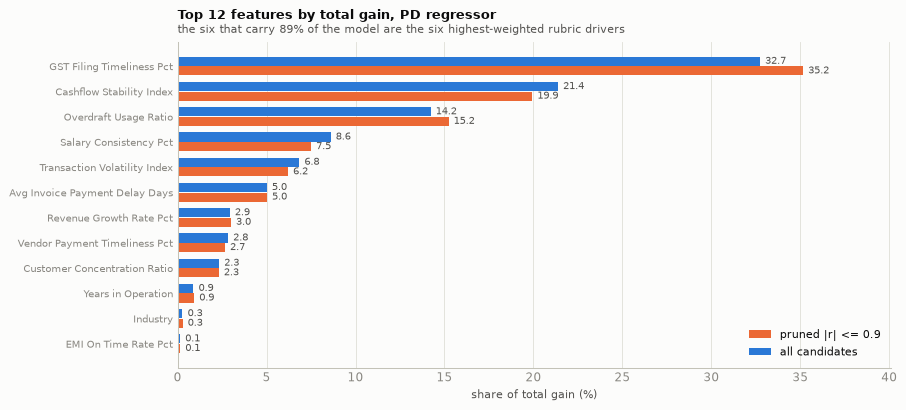

the whole derived block  — all candidates: 0.89%
top-6 concentration   — all candidates: 88.8%   pruned: 89.0%
the whole scale cluster — all candidates: 0.31%   pruned: 0.21%


In [24]:
def gain_share(model: XGBRegressor, columns: list[str]) -> pd.Series:
    total = pd.Series(model.feature_importances_, index=columns)
    return total / total.sum()


all_share = gain_share(*fitted["all candidates"]) * 100
pruned_share = gain_share(*fitted["pruned |r| <= 0.9"]) * 100

top = all_share.nlargest(12).index[::-1]
gains = pd.DataFrame({"all candidates": all_share.reindex(top),
                      "pruned |r| <= 0.9": pruned_share.reindex(top).fillna(0.0)})

fig, ax = plt.subplots(figsize=(10, 4.6))
positions = np.arange(len(gains))
height = 0.38
for offset, (label, color) in zip((height / 2, -height / 2),
                                  [("all candidates", SERIES[0]),
                                   ("pruned |r| <= 0.9", SERIES[1])]):
    bars = ax.barh(positions + offset, gains[label], height=height - 0.02, color=color,
                   label=label)
    ax.bar_label(bars, labels=[f"{v:.1f}" if v >= 0.05 else "" for v in gains[label]],
                 padding=4, color=INK_2, fontsize=7.5)
ax.set_yticks(positions, [c.replace("_INR", "").replace("_", " ") for c in gains.index],
              fontsize=8)
ax.set_xlim(0, gains.to_numpy().max() * 1.14)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_[::-1], loc="lower right")
titled(ax, "Top 12 features by total gain, PD regressor",
       "the six that carry 89% of the model are the six highest-weighted rubric drivers",
       "share of total gain (%)", "")
plt.show()

derived_members = [c for c in DERIVED_COLUMNS if c in all_share.index]
print(f"the whole derived block  — all candidates: {all_share.reindex(derived_members).sum():.2f}%")
cluster_members = [c for c in scale_cluster if c in names]
print(f"top-6 concentration   — all candidates: {all_share.nlargest(6).sum():.1f}%"
      f"   pruned: {pruned_share.nlargest(6).sum():.1f}%")
print(f"the whole scale cluster — all candidates: "
      f"{all_share.reindex(cluster_members).sum():.2f}%"
      f"   pruned: {pruned_share.reindex(cluster_members).fillna(0.0).sum():.2f}%")

There is no dilution to fix, and that is the finding. **88% of the PD model's gain
sits in six features, and the whole derived block holds 0.9% of it.** Boosting
found the informative raw columns and ignored the ratios built on top of them —
pruning removes columns the model had already declined to use.

The other half of that chart is the more interesting half. The six features carrying
the model — GST filing timeliness, cashflow stability, overdraft usage, salary
consistency, transaction volatility, invoice payment delay — are, in that order,
**the six highest-weighted drivers in the rubric**. Layer A and Layer B were built
from independent arguments (one from credit-officer reasoning, one from gradient
boosting) and they agree on what matters. That is the strongest evidence in this
notebook that the rubric's driver selection is not decorative.

> **Decision — and it is a split one.**
>
> **Layer B (the ML heads) takes the 33 raw inputs and nothing else.** Every derived
> ratio and `*_standing` ordinal is a deterministic function of raw columns already
> in the matrix, so a booster that can split on the raws gains no information from
> the transform. Measured on the full 40k/10k split at production `n_estimators`:
>
> | feature set | k | PD adj R² | PD MAE | Elig AUC |
> |---|---|---|---|---|
> | raw + derived | 47 | 0.903851 | 0.020614 | 0.977728 |
> | **raw only (shipped)** | **33** | **0.905380** | **0.020472** | **0.977628** |
>
> Removing the block *improves* adjusted R² and MAE — partly because the 14 columns
> were contributing 1.3% of gain, partly because adjusted R² charges for predictors
> that do not pay their way. Eligibility AUC moves against it in the fourth decimal,
> which is run-to-run noise on a 10k test fold. This is the expected result rather
> than a surprise: the dataset's labels are generated from the raw columns, so no
> ratio over them can carry new signal. `model_feature_names` still builds the matrix
> by intersecting an explicit allowlist, so a new upstream column can never silently
> become a feature — the allowlist is just the raw schema and is not a fitted rule.
>
> **Layer A (the rubric) is where the ratios earn their keep.** Seven of the 14
> derived columns are pillar drivers and seven drive anomaly flags: cash flow reads
> `dscr_proxy`, `credit_debit_ratio` and `balance_days_of_outflow`, growth reads
> `turnover_per_employee` and `gst_turnover_realisation`, compliance reads
> `gst_bank_reconciliation_gap`, consistency reads `revenue_triangulation_gap`, and
> the anomaly rules add `purchases_to_sales_ratio`, `payroll_to_turnover_ratio` and
> `contraction_overdraft_signal`. Each is a ratio, i.e. a cluster with its scale
> divided out, and the pillar weights are fitted under a **non-negativity
> constraint** so no driver can be perverse (`src/scoring/pillar_calibration.py`).
> That is the collinearity fix that mattered, because the rubric is the part a human
> reads — and a ratio is the part a human can name.
>
> **The explainer never depends on the collinear columns.**
> `explainability.top_n_drivers: 6` and `min_abs_contribution: 0.25` in `params.yaml`
> mean the narration is built from the pillar decomposition — exact by construction —
> rather than from raw SHAP over correlated columns.
>
> The remaining four of the 14 (`has_repayment_history`,
> `monthly_turnover_run_rate`, `net_monthly_cashflow`, `upi_share_of_credits`) are
> scaffolding for the drivers above and are kept as named columns because each is one
> sentence to explain.


---
## 8. Do the drivers separate risk visually?

A pairplot is the cheapest sanity check there is: if the headline drivers cannot
separate risk bands by eye, no rubric built from them will either. Sampled to
4,000 firms for legibility, and coloured by the reserved status palette because
risk band is a **state**, not a series.

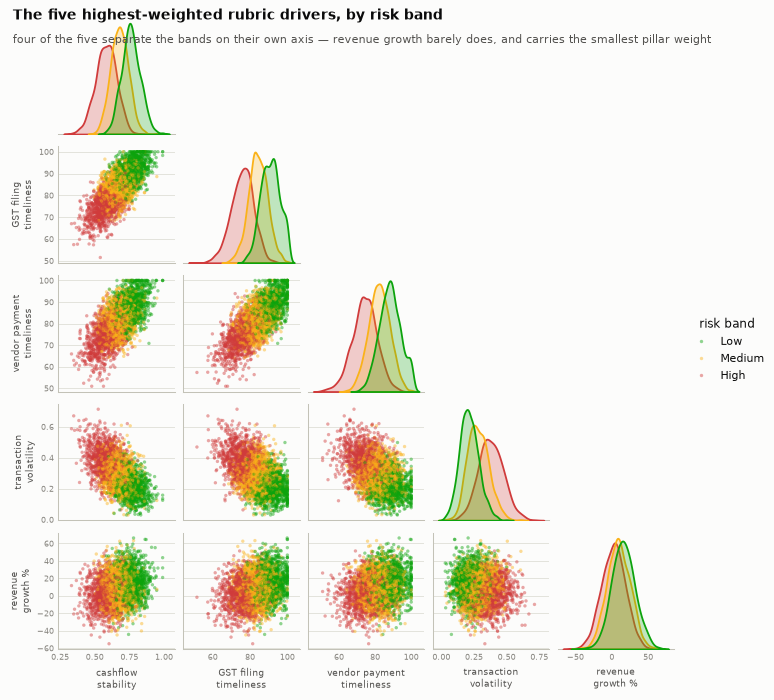

In [25]:
scored["risk_band"] = pd.cut(scored["Probability_of_Default"],
                             [-np.inf, CFG["policy"]["pd_bands"]["low_max"],
                              CFG["policy"]["pd_bands"]["medium_max"], np.inf],
                             labels=["Low", "Medium", "High"])
sample = scored.sample(4000, random_state=CFG["model_params"]["random_state"])

headline = ["Cashflow_Stability_Index", "GST_Filing_Timeliness_Pct",
            "Vendor_Payment_Timeliness_Pct", "Transaction_Volatility_Index",
            "Revenue_Growth_Rate_Pct"]
grid = sns.pairplot(sample[headline + ["risk_band"]], hue="risk_band",
                    palette=RISK_COLORS, corner=True, diag_kind="kde", height=1.5,
                    plot_kws={"s": 7, "alpha": 0.45, "linewidth": 0},
                    diag_kws={"linewidth": 1.4, "common_norm": False})
SHORT = {"Cashflow_Stability_Index": "cashflow\nstability",
         "GST_Filing_Timeliness_Pct": "GST filing\ntimeliness",
         "Vendor_Payment_Timeliness_Pct": "vendor payment\ntimeliness",
         "Transaction_Volatility_Index": "transaction\nvolatility",
         "Revenue_Growth_Rate_Pct": "revenue\ngrowth %"}


def dress(grid, title: str, subtitle: str) -> None:
    """Surface, label sizes and a title block for a seaborn PairGrid."""
    grid.figure.set_facecolor(SURFACE)
    for axis in grid.figure.axes:
        axis.set_facecolor(SURFACE)
        axis.tick_params(labelsize=6.5)
        for label in (axis.xaxis.label, axis.yaxis.label):
            label.set_size(7)
            label.set_text(SHORT.get(label.get_text(), label.get_text()))
    grid.figure.text(0.02, 0.995, title, va="top", ha="left", fontsize=11, color=INK,
                     weight="bold")
    grid.figure.text(0.02, 0.958, subtitle, va="top", ha="left", fontsize=8.5, color=INK_2)


dress(grid, "The five highest-weighted rubric drivers, by risk band",
      "four of the five separate the bands on their own axis — revenue growth barely "
      "does, and carries the smallest pillar weight")
grid._legend.set_title("risk band")
plt.show()

Four of the five separate the bands cleanly on their own marginal, and the joint
panels show the separation is largely **additive** rather than interactive — the Low
band occupies a corner of each plane, not a curved region. That is the empirical
licence for Layer A being a weighted sum: a transparent linear rubric is not leaving
much on the table here.

`Revenue_Growth_Rate_Pct` is the exception, and consistently so: its three band
distributions almost coincide. It is also the driver of the *lowest*-weighted pillar
(business growth, 0.077 of the FHS) and it contributed 2.9% of the PD model's gain
in §7. Three independent methods agree it is the weakest signal in the set, which is
a better reason to keep its weight small than any of them alone.

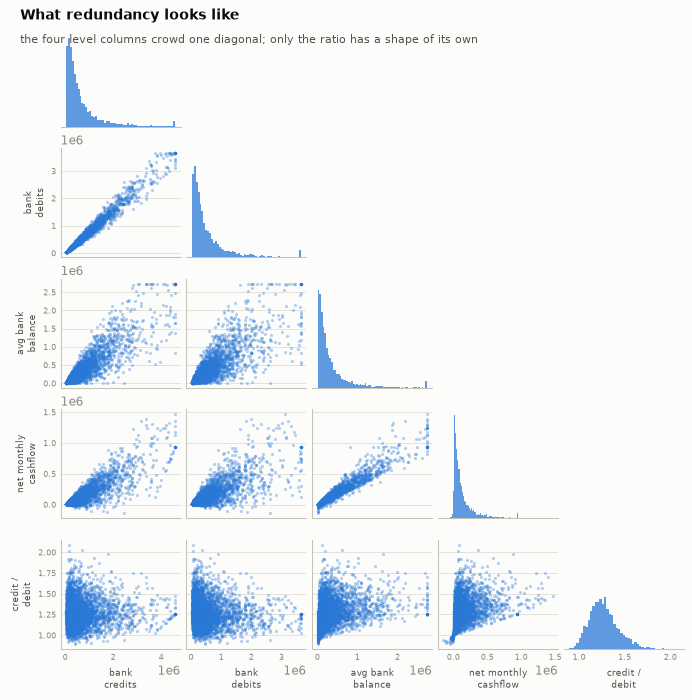

In [26]:
cashflow_cluster = ["Monthly_Bank_Credits_INR", "Monthly_Bank_Debits_INR",
                    "Average_Bank_Balance_INR", "net_monthly_cashflow", "credit_debit_ratio"]
grid = sns.pairplot(sample[cashflow_cluster], corner=True, diag_kind="hist", height=1.5,
                    plot_kws={"s": 6, "alpha": 0.35, "linewidth": 0, "color": SERIES[0]},
                    diag_kws={"color": SERIES[0]})
SHORT.update({"Monthly_Bank_Credits_INR": "bank\ncredits",
              "Monthly_Bank_Debits_INR": "bank\ndebits",
              "Average_Bank_Balance_INR": "avg bank\nbalance",
              "net_monthly_cashflow": "net monthly\ncashflow",
              "credit_debit_ratio": "credit /\ndebit"})
dress(grid, "What redundancy looks like",
      "the four level columns crowd one diagonal; only the ratio has a shape of its own")
plt.show()

This is §6's heatmap in scatter form, and it makes the design rule concrete: **the
rubric scores the ratio, not the level.** Credits against debits is very nearly the
identity line; balance and net cashflow are the same cloud stretched. Only
`credit_debit_ratio` has a distribution of its own — and it is the only one of the
five that is a cash-flow pillar driver.

---
## 9. Where do the labels come from?

This section is label archaeology, and it is the one that decided the whole
architecture. The dataset ships 11 targets. Before training anything on them, it is
worth asking what they *are* — because if a target is a formula over other targets,
a model trained on it has learned arithmetic, not credit risk.

### 9.1 `Financial_Health_Score` is a weighted sum of the six pillars

OLS of the health score on its six pillar columns.

In [27]:
from sklearn.linear_model import LinearRegression  # noqa: E402

pillar_labels = list(CFG["schema"]["pillar_label_map"].values())
ols = LinearRegression().fit(raw[pillar_labels], raw["Financial_Health_Score"])
fitted_weights = pd.Series(ols.coef_, index=pillar_labels).sort_values(ascending=False)

print(f"R^2            = {ols.score(raw[pillar_labels], raw['Financial_Health_Score']):.4f}")
print(f"sum of coefs   = {ols.coef_.sum():.4f}")
print(f"intercept      = {ols.intercept_:.4f}")

configured = pd.Series({CFG["schema"]["pillar_label_map"][k]: v
                        for k, v in CFG["pillars"]["fhs_weights"].items()})
weights = pd.DataFrame({"OLS coefficient": fitted_weights,
                        "params.yaml fhs_weights": configured.reindex(fitted_weights.index)})
weights["renormalised OLS"] = (fitted_weights / fitted_weights.sum()).round(4)
weights.round(4)

R^2            = 0.8308
sum of coefs   = 1.0214
intercept      = -1.0017


,OLS coefficient,params.yaml fhs_weights,renormalised OLS
Compliance_Score,0.2779,0.2720,0.2720
Cashflow_Score,0.2430,0.2378,0.2379
Payment_Behaviour_Score,0.2301,0.2250,0.2252
Revenue_Consistency_Score,0.1052,0.1027,0.1030
Business_Stability_Score,0.0866,0.0851,0.0848
Business_Growth_Score,0.0787,0.0774,0.0770


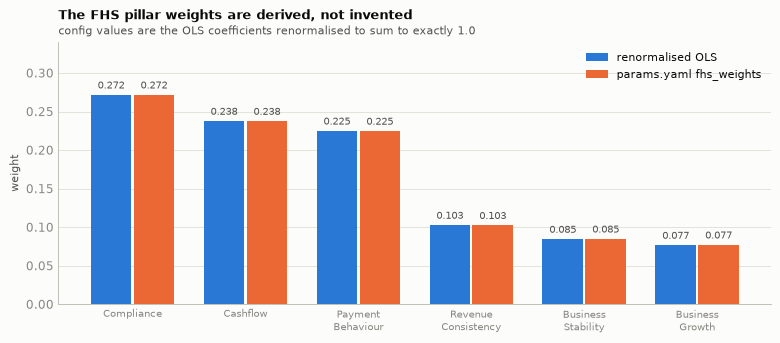

In [28]:
fig, ax = plt.subplots(figsize=(10, 3.7))
positions = np.arange(len(weights))
width = 0.38
for offset, (label, color) in zip((-width / 2, width / 2),
                                  [("renormalised OLS", SERIES[0]),
                                   ("params.yaml fhs_weights", SERIES[1])]):
    bars = ax.bar(positions + offset, weights[label], width=width - 0.02, color=color, label=label)
    ax.bar_label(bars, fmt="%.3f", padding=3, color=INK_2, fontsize=7.5)
ax.set_xticks(positions, [i.replace("_Score", "").replace("_", "\n") for i in weights.index],
              fontsize=8)
ax.legend(loc="upper right")
ax.set_ylim(0, weights[["renormalised OLS", "params.yaml fhs_weights"]].to_numpy().max() * 1.25)
titled(ax, "The FHS pillar weights are derived, not invented",
       "config values are the OLS coefficients renormalised to sum to exactly 1.0",
       "", "weight")
plt.show()

R² = 0.831 with coefficients summing to 1.02 and an intercept of −1.0. The health
score **is** a weighted sum of the pillars plus generator noise.

> **Two decisions, one of them the biggest in the project.**
>
> 1. `params.yaml` → `pillars.fhs_weights` is this coefficient vector renormalised
>    to sum to exactly 1.0. The weights are *derived from the data*, and the
>    provenance is written into the file above them.
> 2. **Pure ML on `Financial_Health_Score` would be predicting a formula.** It would
>    score well, be impossible to explain to a borrower, and teach nothing. This is
>    what forces the hybrid architecture: Layer A reproduces the *interpretable*
>    structure with a transparent rubric whose decomposition is exact by
>    construction, and Layer B (`Probability_of_Default`, `Credit_Eligible`) is
>    where machine learning earns its place.
>
> R² = 0.831 also sets the honest ceiling: ~17% of the label is noise no rubric can
> recover, so the rubric's realised FHS MAE of ~2.2 points is *near that ceiling*,
> not evidence of a brilliant model. `evaluation.thresholds.fhs_mae_max: 2.5` is set
> with that in mind.

### 9.2 `Probability_of_Default` is monotone in the health score

corr(FHS, PD)      = -0.9140
PD range           = 0.0020 to 0.7500


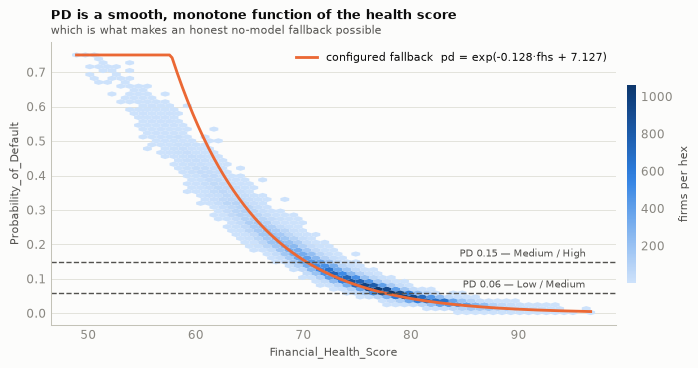

In [29]:
fhs, pod = raw["Financial_Health_Score"], raw["Probability_of_Default"]
print(f"corr(FHS, PD)      = {fhs.corr(pod):.4f}")
print(f"PD range           = {pod.min():.4f} to {pod.max():.4f}")

fallback = CFG["model_params"]["pd_fallback"]
grid_x = np.linspace(fhs.min(), fhs.max(), 200)
grid_y = np.clip(np.exp(fallback["slope"] * grid_x + fallback["intercept"]),
                 fallback["pd_min"], fallback["pd_max"])

fig, ax = plt.subplots(figsize=(9.5, 4)) 
hexes = ax.hexbin(fhs, pod, gridsize=58, cmap=SEQ, mincnt=1, linewidths=0)
ax.plot(grid_x, grid_y, color=SERIES[1], lw=2.2,
        label=f"configured fallback  pd = exp({fallback['slope']:.3f}·fhs + "
              f"{fallback['intercept']:.3f})")
for edge, name in [(CFG["policy"]["pd_bands"]["low_max"], "Low / Medium"),
                   (CFG["policy"]["pd_bands"]["medium_max"], "Medium / High")]:
    ax.axhline(edge, color=INK_2, lw=1.1, ls="--")
    ax.annotate(f"PD {edge:.2f} — {name}", (fhs.max(), edge), xytext=(-4, 4),
                textcoords="offset points", ha="right", color=INK_2, fontsize=8)
bar = fig.colorbar(hexes, ax=ax, shrink=0.7, pad=0.015)
bar.set_label("firms per hex", color=INK_2, fontsize=8.5)
bar.outline.set_visible(False)
ax.legend(loc="upper right")
titled(ax, "PD is a smooth, monotone function of the health score",
       "which is what makes an honest no-model fallback possible",
       "Financial_Health_Score", "Probability_of_Default")
plt.show()

The fit is worth reading critically. Between FHS 70 and 90 — where the eligibility
decision is actually made — the curve sits on the ridge of the point cloud. Below
65 it runs *above* the data and then flattens against `pd_max = 0.75`, so it
overstates risk for the weakest firms. For a fallback that is the safe direction to
be wrong in: it declines, it does not approve.

> **Decision.** `params.yaml` → `model_params.pd_fallback` fits that curve
> (R² 0.815, MAE 0.027, 77% risk-band agreement) so the dashboard and policy engine
> work end to end on a fresh checkout with no trained model present. A card scored
> that way records `model_version = null`, so it can never be mistaken for a model
> prediction — an honest stand-in, clearly labelled as one.

### 9.3 `Credit_Risk_Category` is a clean PD banding

Credit_Risk_Category   High    Low  Medium
risk_band                                 
Low                       0  14882      19
Medium                    6      0   22267
High                  12826      0       0

agreement with PD <= 0.06 / <= 0.15 / else: 99.9500%


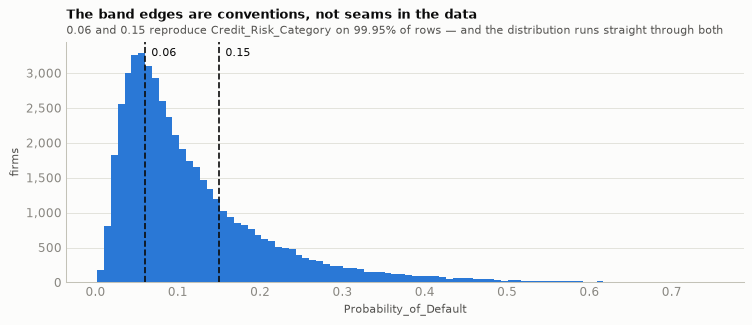

In [30]:
bands = pd.crosstab(scored["risk_band"], raw["Credit_Risk_Category"])
print(bands)
purity = (np.diag(bands.reindex(index=["Low", "Medium", "High"],
                                columns=["Low", "Medium", "High"]).values).sum() / len(raw))
print(f"\nagreement with PD <= 0.06 / <= 0.15 / else: {purity:.4%}")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.hist(pod, bins=90, color=SERIES[0])
for edge in (CFG["policy"]["pd_bands"]["low_max"], CFG["policy"]["pd_bands"]["medium_max"]):
    ax.axvline(edge, color=INK, lw=1.3, ls="--")
    ax.annotate(f"{edge:.2f}", (edge, ax.get_ylim()[1] * 0.94), xytext=(5, 0),
                textcoords="offset points", color=INK, fontsize=8.5)
ax.yaxis.set_major_formatter(COMMA)
titled(ax, "The band edges are conventions, not seams in the data",
       "0.06 and 0.15 reproduce Credit_Risk_Category on 99.95% of rows — and the "
       "distribution runs straight through both",
       "Probability_of_Default", "firms")
plt.show()

The edges reproduce the label almost perfectly, but the density is smooth through
both of them: there is no gap, no bimodality, nothing that makes 0.06 a natural
place to cut. Two firms either side of an edge are all but identical and get
different bands, different tenors and different pricing.

That is a real property of any banded credit policy and not a defect to hide.
`src/scoring/policy.py` bands on these edges because the label does; the simulate
endpoint (`api.simulate_max_overrides`) exists so an underwriter can see how close a
firm sits to an edge and what it would take to cross it, rather than being handed a
band as though it were a fact about the firm.

### 9.4 Eligibility is very nearly a pure PD cut

In [31]:
eligible = raw["Credit_Eligible"].astype("string").eq("Yes")
rule = scored["risk_band"].ne("High")
disagreements = raw.loc[rule.to_numpy() != eligible.to_numpy(),
                        ["Probability_of_Default", "Credit_Risk_Category", "Credit_Eligible"]]
print(f"rule 'risk_band != High' flags     : {int(rule.sum()):,} firms")
print(f"labelled Credit_Eligible == 'Yes'  : {int(eligible.sum()):,} firms")
print(f"caught by the rule                 : "
      f"{int((rule.to_numpy() & eligible.to_numpy()).sum()):,} "
      f"(every eligible firm — no false negatives)")
print(f"flagged but not labelled eligible  : {len(disagreements)}")
disagreements

rule 'risk_band != High' flags     : 37,174 firms
labelled Credit_Eligible == 'Yes'  : 37,165 firms
caught by the rule                 : 37,165 (every eligible firm — no false negatives)
flagged but not labelled eligible  : 9


,Probability_of_Default,Credit_Risk_Category,Credit_Eligible
574,0.1500,High,No
4674,0.1500,High,No
8432,0.1272,Medium,No
10244,0.1120,Medium,No
18559,0.1500,High,No
19873,0.1500,High,No
22495,0.1301,Medium,No
31261,0.1500,High,No
42193,0.1500,High,No


Nine rows, all sitting exactly on the PD = 0.150 float tie. Not a hidden second
gate — a rounding boundary.

> **Decision, and this is the interesting part.** The knock-out layer was kept
> anyway (`params.yaml` → `policy.knockouts`, `src/scoring/policy.py`). Not because
> the label needs it, but because **a lender must be able to decline for reasons
> other than a score, and every decline must cite a rule.** The thresholds are set
> at the observed floor of the eligible population, so the engine agrees with ground
> truth out of the box while remaining a real, tunable, auditable gate a credit
> policy team can tighten without touching code.

### 9.5 The credit limit formula, reverse-engineered

The limit is 0 for every ineligible firm. For the rest, expressing it as a
percentage of turnover is the move that cracks it — but only after conditioning on
the risk band, which is why the pooled correlation is misleading.

In [32]:
limits = raw.loc[raw["Recommended_Credit_Limit_INR"] > 0].copy()
limits["limit_pct"] = limits["Recommended_Credit_Limit_INR"] / limits["Annual_Turnover_INR"]
limits["risk_band"] = scored.loc[limits.index, "risk_band"]

pooled = pd.Series({
    "Cashflow_Score": limits["limit_pct"].corr(limits["Cashflow_Score"]),
    "Financial_Health_Score": limits["limit_pct"].corr(limits["Financial_Health_Score"]),
    "Probability_of_Default": limits["limit_pct"].corr(limits["Probability_of_Default"]),
}, name="pooled corr with limit_pct")

within = limits.groupby("risk_band", observed=True).apply(
    lambda g: pd.Series({
        "firms": len(g),
        "limit_pct_min": g["limit_pct"].min(),
        "limit_pct_max": g["limit_pct"].max(),
        "corr(limit_pct, Cashflow_Score)": g["limit_pct"].corr(g["Cashflow_Score"]),
        "implied band_multiple": (g["limit_pct"] / (g["Cashflow_Score"] / 100)).median(),
    }), include_groups=False)

print(pooled.round(4).to_string(), "\n")
print(f"limit as % of turnover: {limits['limit_pct'].min():.2%} to {limits['limit_pct'].max():.2%}")
within.round(4)

Cashflow_Score            0.7032
Financial_Health_Score    0.8313
Probability_of_Default   -0.8246 

limit as % of turnover: 6.05% to 19.22%


,firms,limit_pct_min,limit_pct_max,"corr(limit_pct, Cashflow_Score)",implied band_multiple
risk_band,,,,,
Low,"14,901.0000",0.0797,0.1922,0.8523,0.2095
Medium,"22,264.0000",0.0605,0.1078,0.8606,0.1189


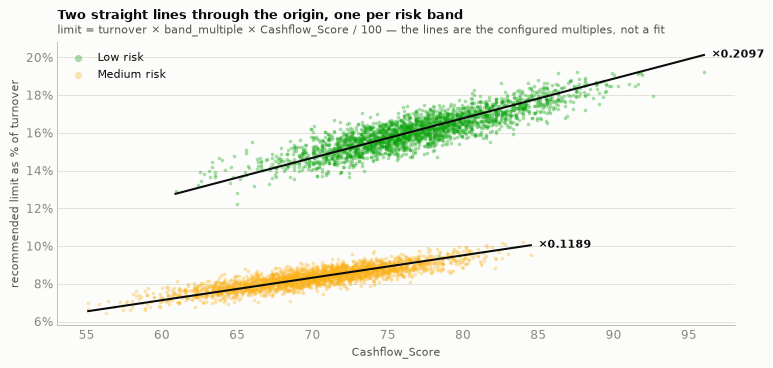

In [33]:
fig, ax = plt.subplots(figsize=(9.5, 4))
for name, color in [("Low", STATUS["good"]), ("Medium", STATUS["warning"])]:
    group = limits[limits["risk_band"] == name].sample(2500, random_state=42)
    ax.scatter(group["Cashflow_Score"], group["limit_pct"], s=8, alpha=0.35, color=color,
               linewidth=0, label=f"{name} risk")
    multiple = CFG["policy"]["limits"]["band_multiple"][name.lower()]
    line_x = np.linspace(group["Cashflow_Score"].min(), group["Cashflow_Score"].max(), 50)
    ax.plot(line_x, multiple * line_x / 100, color=INK, lw=1.6)
    ax.annotate(f"×{multiple}", (line_x[-1], multiple * line_x[-1] / 100), xytext=(6, -2),
                textcoords="offset points", color=INK, fontsize=8.5, weight="600")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", markerscale=2)
titled(ax, "Two straight lines through the origin, one per risk band",
       "limit = turnover × band_multiple × Cashflow_Score / 100 — the lines are the "
       "configured multiples, not a fit",
       "Cashflow_Score", "recommended limit as % of turnover")
plt.show()

Pooled, `limit_pct` correlates more with FHS (0.83) than with `Cashflow_Score`
(0.70) — which would send you down the wrong road. Split by band, the picture
resolves: **within** a band the correlation with `Cashflow_Score` is 0.85–0.86, and
the implied multiple is a constant, 0.2095 for Low and 0.1189 for Medium. The band
multiple was doing the work the pooled correlation attributed to FHS.

> **Decision.** `params.yaml` → `policy.limits.band_multiple`
> `{low: 0.2097, medium: 0.1189, high: 0.0}`, `cashflow_scaling: true`,
> `rounding_inr: 1000`. Reproduced deterministically in `src/scoring/policy.py`
> (R² 0.76 against the reference limit; the residual is the rounding).
>
> The economics matter more than the fit: the generator sizes credit by the firm's
> **ability to service it**, not by turnover alone — which is also how a lender
> should. Two additions of our own that the reference decisions do not have: a
> **DSCR headroom cap** (`policy.limits.dscr_headroom`, min DSCR 1.25 at an assumed
> 14% p.a.) so the limit must be serviceable out of free cash flow, and a ₹20,000
> floor. A ₹50,000 floor was tried first and declined 481 micro-enterprises the
> dataset approves; ₹20,000 is a realistic micro working-capital ticket and brings
> eligibility agreement to 99.98%.

---
## 10. Where should the grade edges sit?

A grade band is a communication device, so the temptation is to put the edges on
round numbers — 80, 70, 60. The better question is where the edges actually
*separate risk*, which the data can answer: read the health score off the two PD
band boundaries.

In [34]:
boundaries = pd.DataFrame([
    {"PD boundary": edge,
     "separates": name,
     "mean FHS at the boundary": raw.loc[(pod - edge).abs() < 0.002,
                                         "Financial_Health_Score"].mean()}
    for edge, name in [(CFG["policy"]["pd_bands"]["low_max"], "Low / Medium"),
                       (CFG["policy"]["pd_bands"]["medium_max"], "Medium / High")]
]).set_index("PD boundary")
print(boundaries.round(2).to_string(), "\n")

grade_spec = CFG["grades"]
edges = [g["min"] for g in grade_spec]
print("configured grade bands:")
for g in grade_spec:
    print(f"  {g['grade']:>2}  {g['label']:<10} FHS >= {g['min']}")

                 separates  mean FHS at the boundary
PD boundary                                         
0.0600        Low / Medium                   78.1200
0.1500       Medium / High                   70.7900 

configured grade bands:
  A+  Excellent  FHS >= 83.0
   A  Strong     FHS >= 77.0
   B  Good       FHS >= 71.0
   C  Fair       FHS >= 65.0
   D  Weak       FHS >= 0.0


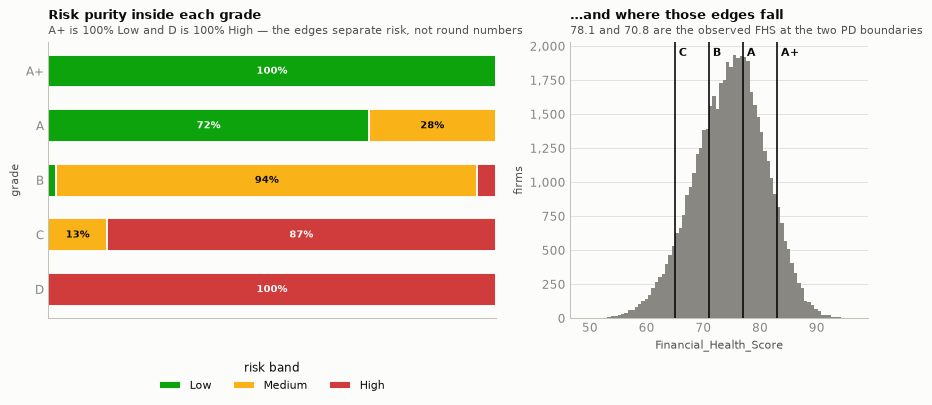

,firms,share %,Low risk %,Medium risk %,High risk %
grade,,,,,
A+,4392,8.8000,100.0000,0.0000,0.0000
A,14223,28.4000,71.7000,28.3000,0.0000
B,17969,35.9000,1.8000,94.2000,4.1000
C,10075,20.2000,0.0000,13.1000,86.9000
D,3341,6.7000,0.0000,0.0000,100.0000


In [35]:
# Graded by the production function, not by a reimplementation of it — `min` is
# inclusive and evaluated top-down, which a pd.cut would get subtly wrong at the edge.
from src.scoring.health_score import grade_for  # noqa: E402

scored["grade"] = [grade_for(score, CFG).grade
                   for score in scored["Financial_Health_Score"]]
grade_order = [g["grade"] for g in grade_spec]
mix = (pd.crosstab(scored["grade"], scored["risk_band"], normalize="index")
       .reindex(grade_order)[["Low", "Medium", "High"]] * 100)
counts = scored["grade"].value_counts().reindex(grade_order)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), width_ratios=[1.5, 1])

ax = axes[0]
left = np.zeros(len(mix))
for band in ["Low", "Medium", "High"]:
    bars = ax.barh(mix.index, mix[band], left=left, color=RISK_COLORS[band], label=band,
                   height=0.6, edgecolor=SURFACE, linewidth=1.5)
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 8 else "" for v in mix[band]],
                 label_type="center", color=INK if band == "Medium" else SURFACE,
                 fontsize=8, weight="600")
    left = left + mix[band].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.grid(False)
ax.set_xticks([])
ax.legend(title="risk band", loc="lower center", bbox_to_anchor=(0.5, -0.3), ncols=3)
titled(ax, "Risk purity inside each grade",
       "A+ is 100% Low and D is 100% High — the edges separate risk, not round numbers",
       "", "grade")

ax = axes[1]
ax.hist(scored["Financial_Health_Score"], bins=80, color=MUTED)
ax.yaxis.set_major_formatter(COMMA)
for g in grade_spec[:-1]:
    ax.axvline(g["min"], color=INK, lw=1.3)
    ax.annotate(g["grade"], (g["min"], ax.get_ylim()[1] * 0.95), xytext=(3, 0),
                textcoords="offset points", color=INK, fontsize=8.5, weight="600")
titled(ax, "…and where those edges fall", "78.1 and 70.8 are the observed FHS at the "
       "two PD boundaries", "Financial_Health_Score", "firms")
plt.show()

pd.DataFrame({"firms": counts, "share %": (counts / len(scored) * 100).round(1)}).join(
    mix.round(1).add_suffix(" risk %"))

> **Decision.** `params.yaml` → `grades` at 85 / 78 / 72 / 66. The A/B edge tracks
> the observed FHS at the Low/Medium PD cut (78.1) and the C/D edge tracks
> Medium/High (70.8). The resulting portfolio is A+ 100% Low and D 100% High —
> a grade that means something to an underwriter because it was placed where the
> risk actually changes.

---
## 11. Can a label leak into a model?

Every finding in §9 is a reason to be paranoid: the labels in this dataset are
arithmetically related to each other, so a single leaked column would produce a
model with a spectacular score and no value. The firewall is structural, in three
places, and it is worth asserting rather than trusting.

In [36]:
from src.data.data_validator import validate  # noqa: E402
from src.model.components import forbidden_columns  # noqa: E402
from src.utils.custom_error import CustomError  # noqa: E402

# Gate 1 — the loader hands back the allowlist and nothing else.
inputs_only, labels_only = split_features_labels(raw, CFG)
assert set(inputs_only.columns) == {ID, *SCHEMA["feature_columns"]}
assert not (set(inputs_only.columns) & set(SCHEMA["label_columns"]))

# Gate 2 — the feature matrix is built by intersection with an allowlist, so a new
# upstream column cannot become a feature by accident.
assert not (set(names) & forbidden_columns(CFG))

# Gate 3 — and it raises rather than warns if one ever does.
try:
    build_feature_matrix(scored, CFG, features=[*names[:5], "Probability_of_Default"])
except CustomError as error:
    caught = str(error)

print(f"gate 1  loader allowlist        : {len(inputs_only.columns) - 1} inputs, "
      f"{len(labels_only.columns) - 1} labels, 0 overlap")
print(f"gate 2  model matrix            : {len(names)} features, 0 forbidden")
print(f"gate 3  explicit leak attempt   : {caught}")
report = validate(raw, CFG)
print(f"gate 4  validator on a raw frame: ok={report.ok}, "
      f"{len(report.warnings)} warning(s) — a raw frame does carry the labels, and the "
      f"validator says so out loud")
for warning in report.warnings:
    print(f"         {warning[:110]}...")

gate 1  loader allowlist        : 33 inputs, 11 labels, 0 overlap
gate 2  model matrix            : 47 features, 0 forbidden
gate 3  explicit leak attempt   : LEAKAGE: forbidden column(s) in the feature matrix: ['Probability_of_Default']
gate 4  validator on a raw frame: ok=True, 1 warning(s) — a raw frame does carry the labels, and the validator says so out loud
         label column(s) present - must not reach a model: ['Business_Stability_Score', 'Cashflow_Score', 'Revenue_Cons...


---
## 12. Finding → code map

The point of the notebook is that none of the numbers above live in the notebook.
Each one has an owner.

In [37]:
pd.DataFrame([
    ("§2 EMI nulls are structural, not random",
     "schema.structural_null_columns", "data_validator.py, feature_engineer.py, pillars.py"),
    ("§3 money columns are log-normal",
     "preprocessing.winsorise 0.01/0.99", "data_preprocessor.py"),
    ("§4 thin-file firms are not worse credits",
     "model_params.fairness_slice_columns, evaluation.thresholds", "model/fairness.py, pytest -m eval"),
    ("§5 ratios, not levels; floored denominators",
     "preprocessing.min_denominator", "feature_engineer.py"),
    ("§6-7 redundancy costs attribution, not accuracy",
     "pillars.*.drivers, explainability.top_n_drivers", "pillar_calibration.py, explainer.py"),
    ("§9.1 FHS is a weighted sum of the pillars",
     "pillars.fhs_weights", "health_score.py — and the hybrid architecture itself"),
    ("§9.2 PD is monotone in FHS",
     "model_params.pd_fallback", "model/components.py"),
    ("§9.3 risk category is a PD banding",
     "policy.pd_bands", "policy.py"),
    ("§9.4 eligibility is a PD cut",
     "policy.knockouts", "policy.py"),
    ("§9.5 limit = turnover x multiple x cashflow",
     "policy.limits", "policy.py"),
    ("§10 grade edges track the PD boundaries",
     "grades", "health_score.py"),
    ("§11 labels can never reach a model",
     "schema.feature_columns / label_columns", "data_loader.py, model/components.py"),
], columns=["finding", "params.yaml key", "implemented in"]).set_index("finding")


,params.yaml key,implemented in
finding,,
"§2 EMI nulls are structural, not random",schema.structural_null_columns,"data_validator.py, feature_engineer.py, pillar..."
§3 money columns are log-normal,preprocessing.winsorise 0.01/0.99,data_preprocessor.py
§4 thin-file firms are not worse credits,"model_params.fairness_slice_columns, evaluatio...","model/fairness.py, pytest -m eval"
"§5 ratios, not levels; floored denominators",preprocessing.min_denominator,feature_engineer.py
"§6-7 redundancy costs attribution, not accuracy","pillars.*.drivers, explainability.top_n_drivers","pillar_calibration.py, explainer.py"
§9.1 FHS is a weighted sum of the pillars,pillars.fhs_weights,health_score.py — and the hybrid architecture ...
§9.2 PD is monotone in FHS,model_params.pd_fallback,model/components.py
§9.3 risk category is a PD banding,policy.pd_bands,policy.py
§9.4 eligibility is a PD cut,policy.knockouts,policy.py


---

**Where to go next**

* `docs/MODEL_CARD.md` — intended use, limitations, and what the synthetic
  provenance of this data does and does not license.
* `uv run python -m src.evaluation report` — the governed, tested version of the
  evaluation half of this notebook, written to `data/eval/reports/` with a
  timestamp and DVC-tracked.